In [1]:
import os

print(os.getcwd())
print(os.listdir())

/home/arsh/Desktop/ai in healthcare/lab 2
['Lab-2 (E23CSEU0301).ipynb']


In [17]:
import pandas as pd

df = pd.read_csv("heart_failure_clinical_records_dataset - Copy.csv")

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [18]:
# Number of rows and columns
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Number of Rows: 299
Number of Columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


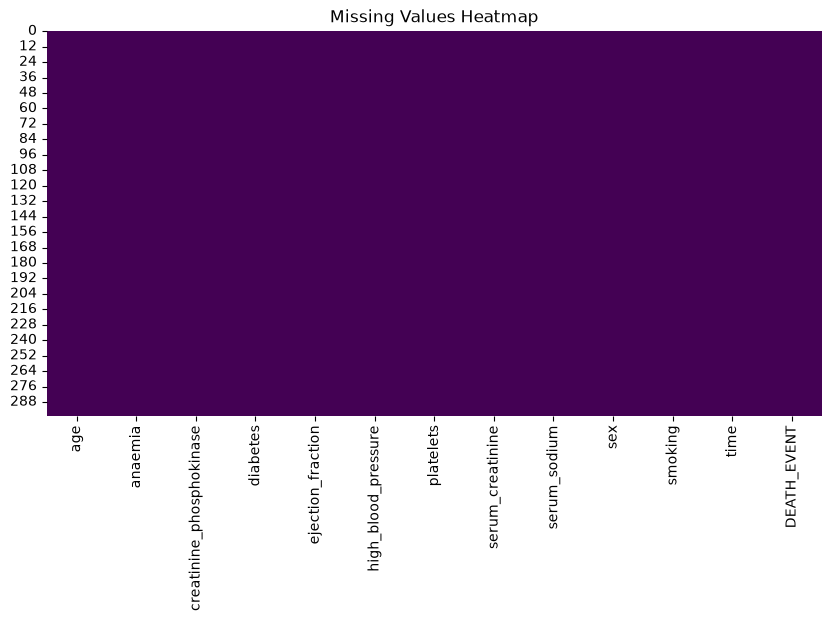

In [19]:
##Task 4
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")

plt.title("Missing Values Heatmap")
plt.show()

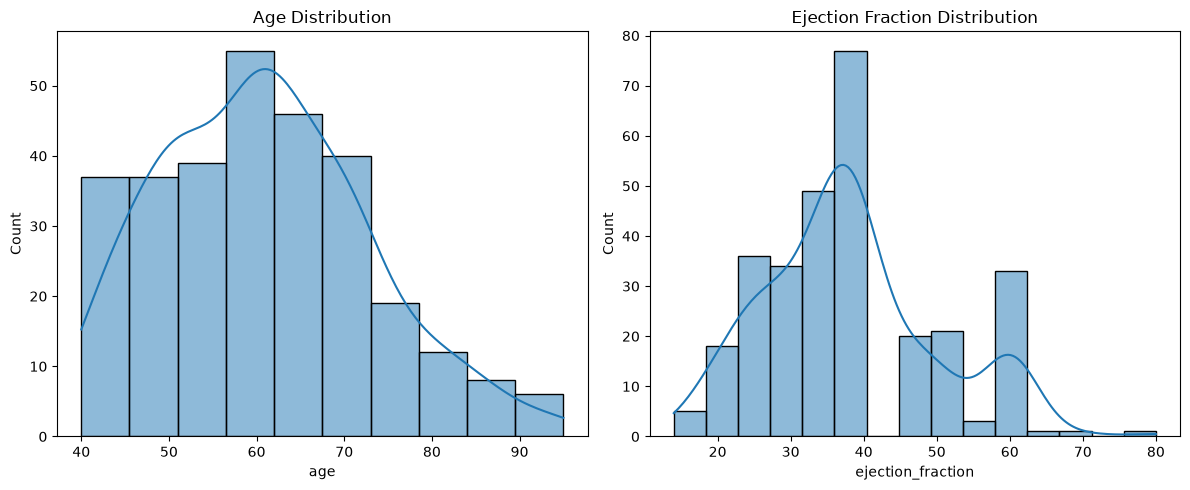

In [20]:
## Task 5
plt.figure(figsize=(12, 5))

# Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")

# Ejection Fraction Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['ejection_fraction'], kde=True)
plt.title("Ejection Fraction Distribution")

plt.tight_layout()
plt.show()

In [21]:
##Task 6: Impute Missing Values
# Numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_cols = ['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Check missing values after imputation
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [22]:
# Task 7: Remove Outliers
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Remove outliers using IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (224, 13)


In [23]:
# Task 8: Correct Inconsistencies
# Check for invalid age values
print("Negative age values:", (df['age'] < 0).sum())

# Remove invalid age values
df = df[df['age'] >= 0]

print("Dataset shape after fixing inconsistencies:", df.shape)

Negative age values: 0
Dataset shape after fixing inconsistencies: (224, 13)


In [24]:
# Task 9: Feature Engineering
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Create age_group
df['age_group'] = np.select(
    [
        df['age'] < 40,
        (df['age'] >= 40) & (df['age'] <= 60),
        df['age'] > 60
    ],
    [
        '<40',
        '40-60',
        '>60'
    ],
    default='Unknown'
)

# Create risk_score
df['risk_score'] = df['ejection_fraction'] * df['serum_creatinine']

# Normalize risk_score
scaler = MinMaxScaler()
df['risk_score'] = scaler.fit_transform(df[['risk_score']])

# Display new features
df[['age', 'age_group', 'ejection_fraction', 'serum_creatinine', 'risk_score']].head()

,age,age_group,ejection_fraction,serum_creatinine,risk_score
0,75.0,>60,20,1.9,0.310545
2,65.0,>60,20,1.3,0.171495
3,50.0,40-60,20,1.9,0.310545
5,90.0,>60,40,2.1,0.843569
6,75.0,>60,15,1.2,0.078795


In [25]:
# Task 10: Encode Categorical Variables
from sklearn.preprocessing import LabelEncoder

# Create LabelEncoder object
le = LabelEncoder()

# Encode age_group
df['age_group_encoded'] = le.fit_transform(df['age_group'])

# Display result
df[['age_group', 'age_group_encoded']].head()

,age_group,age_group_encoded
0,>60,1
2,>60,1
3,40-60,0
5,>60,1
6,>60,1


In [26]:
# Task 11: Normalize Features
# from sklearn.preprocessing import MinMaxScaler

# # Select numerical features to normalize
# columns_to_normalize = ['age', 'platelets']

# # Create scaler
# scaler = MinMaxScaler()

# # Normalize the columns
# df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

# # Display normalized data
# df[columns_to_normalize].head()

# Save data before normalization
df_before_cleaning = df.copy()

# Task 11: Normalize Features

from sklearn.preprocessing import MinMaxScaler

# Select numerical features to normalize
columns_to_normalize = ['age', 'platelets']

# Create scaler
scaler = MinMaxScaler()

# Normalize the columns
df[columns_to_normalize] = scaler.fit_transform(df[columns_to_normalize])

# Display normalized data
df[columns_to_normalize].head()

,age,platelets
0,0.636364,0.468852
2,0.454545,0.131148
3,0.181818,0.288525
5,0.909091,0.268852
6,0.636364,0.016393


In [27]:
# Task 12: Compute Summary Statistics

# Before normalization
numerical_before = df_before_cleaning.select_dtypes(include=['int64', 'float64'])

summary_before = pd.DataFrame({
    'Mean': numerical_before.mean(),
    'Median': numerical_before.median(),
    'Standard Deviation': numerical_before.std()
})

print("BEFORE NORMALIZATION")
print(summary_before)


# After normalization
numerical_after = df.select_dtypes(include=['int64', 'float64'])

summary_after = pd.DataFrame({
    'Mean': numerical_after.mean(),
    'Median': numerical_after.median(),
    'Standard Deviation': numerical_after.std()
})

print("\nAFTER NORMALIZATION")
print(summary_after)

BEFORE NORMALIZATION
                                   Mean         Median  Standard Deviation
age                           60.809527      60.000000           11.946085
anaemia                        0.468750       0.000000            0.500140
creatinine_phosphokinase     336.941964     212.000000          279.521085
diabetes                       0.419643       0.000000            0.494606
ejection_fraction             38.178571      38.000000           11.710801
high_blood_pressure            0.379464       0.000000            0.486340
platelets                 255865.190045  262500.000000        67153.749051
serum_creatinine               1.128571       1.100000            0.327794
serum_sodium                 137.044643     137.000000            3.806740
sex                            0.642857       1.000000            0.480231
smoking                        0.321429       0.000000            0.468071
time                         132.651786     120.000000           76.579770
DEAT

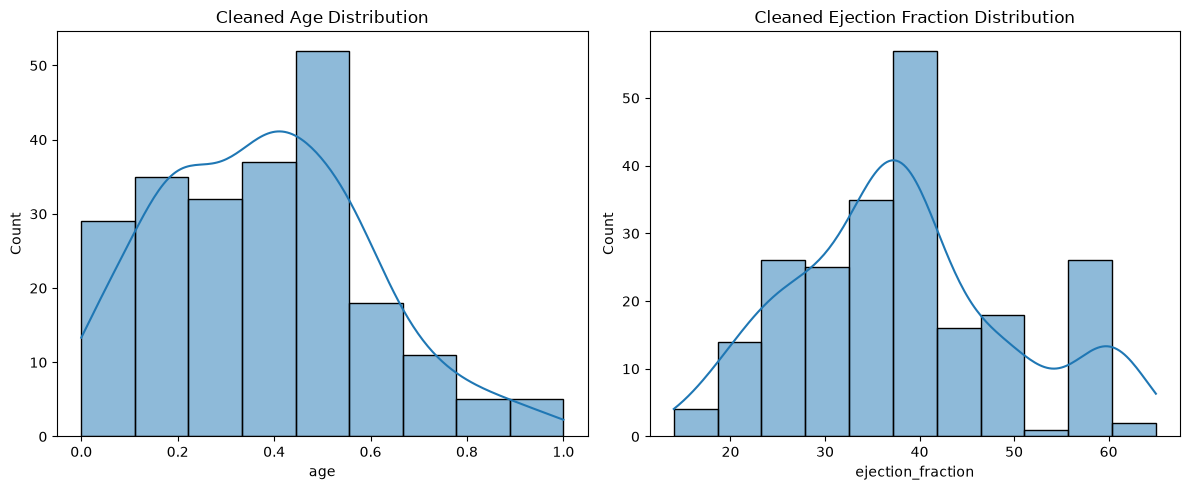

In [28]:
# Task 13: Validate Cleaning
plt.figure(figsize=(12, 5))

# Cleaned Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['age'], kde=True)
plt.title("Cleaned Age Distribution")

# Cleaned Ejection Fraction Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['ejection_fraction'], kde=True)
plt.title("Cleaned Ejection Fraction Distribution")

plt.tight_layout()
plt.show()

In [29]:
# Task 14: Check Missing Values
# Check missing values after cleaning
print("Missing values in cleaned dataset:")
print(df.isnull().sum())

# Total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values in cleaned dataset:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
age_group                   0
risk_score                  0
age_group_encoded           0
dtype: int64

Total missing values: 0
